In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    accuracy_score,
    roc_curve,
    auc,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress convergence warnings for cleaner output
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Load the data
nn_df = pd.read_csv("insurance_fraud_data_processed.csv")
nn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9249 entries, 0 to 9248
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   claim_number        9249 non-null   int64  
 1   age_of_driver       9249 non-null   int64  
 2   gender              9249 non-null   object 
 3   marital_status      9249 non-null   int64  
 4   safety_rating       9249 non-null   int64  
 5   annual_income       9249 non-null   float64
 6   high_education      9249 non-null   int64  
 7   address_change      9249 non-null   int64  
 8   property_status     9249 non-null   object 
 9   zip_code            9249 non-null   int64  
 10  claim_date          9249 non-null   object 
 11  claim_day_of_week   9249 non-null   object 
 12  accident_site       9249 non-null   object 
 13  past_num_of_claims  9249 non-null   int64  
 14  witness_present     9249 non-null   float64
 15  liab_prct           9249 non-null   int64  
 16  channe

In [2]:
nn_df.describe()

,claim_number,age_of_driver,marital_status,safety_rating,annual_income,high_education,address_change,zip_code,past_num_of_claims,witness_present,liab_prct,police_report,age_of_vehicle,vehicle_price,total_claim,injury_claim,policy deductible,annual premium,days open,form defects
count,9.249000e+03,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000,9249.000000
mean,3.231217e+08,43.224781,0.715645,73.824305,60015.810540,0.697697,0.573359,49924.088226,0.485025,0.235701,49.706347,0.601795,4.971348,21920.101452,21687.848973,4888.299329,1010.325441,1268.943454,8.768534,3.956320
std,1.734202e+08,11.887665,0.451131,15.291783,4861.635116,0.459281,0.494616,29087.651958,0.941646,0.424459,33.467361,0.489555,2.225001,10461.063881,10460.030301,2021.933844,561.455096,229.598981,2.430818,1.977882
min,2.280960e+05,19.000000,0.000000,2.000000,45519.360000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2261.507903,2583.428985,547.029169,500.000000,653.660000,2.303305,0.000000
25%,1.789932e+08,34.000000,0.000000,66.000000,56884.800000,0.000000,0.000000,20112.000000,0.000000,0.000000,18.000000,0.000000,3.000000,13900.879610,13567.300360,3352.793086,500.000000,1082.360000,7.991217,3.000000
50%,3.177585e+08,43.000000,1.000000,77.000000,60185.600000,1.000000,1.000000,50028.000000,0.000000,0.000000,50.000000,1.000000,5.000000,20260.724040,19954.097450,4640.142346,1000.000000,1239.060000,9.263043,4.000000
75%,4.708524e+08,50.000000,1.000000,85.000000,63208.000000,1.000000,1.000000,80037.000000,1.000000,0.000000,81.000000,1.000000,6.000000,28525.420980,28218.722280,6198.491883,1000.000000,1383.490000,10.299194,5.000000
max,6.219556e+08,100.000000,1.000000,100.000000,76254.400000,1.000000,1.000000,85083.000000,6.000000,1.000000,100.000000,1.000000,14.000000,52124.564900,52156.424940,10701.051670,2000.000000,1829.630000,15.177169,13.000000


In [3]:
nn_df.isnull().sum()

claim_number          0
age_of_driver         0
gender                0
marital_status        0
safety_rating         0
annual_income         0
high_education        0
address_change        0
property_status       0
zip_code              0
claim_date            0
claim_day_of_week     0
accident_site         0
past_num_of_claims    0
witness_present       0
liab_prct             0
channel               0
police_report         0
age_of_vehicle        0
vehicle_category      0
vehicle_price         0
vehicle_color         0
total_claim           0
injury_claim          0
policy deductible     0
annual premium        0
days open             0
form defects          0
fraud reported        0
dtype: int64

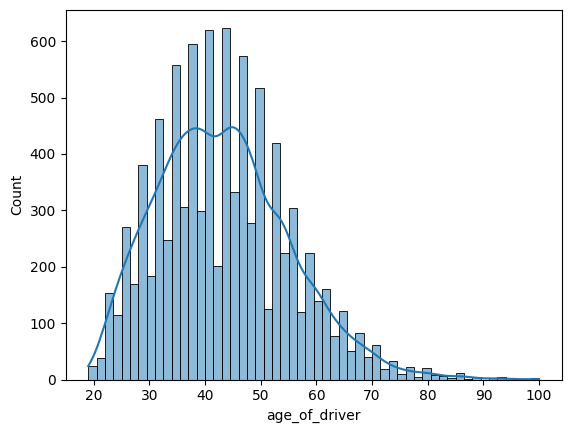

In [4]:
sns.histplot(nn_df["age_of_driver"], kde=True)
plt.show()

In [5]:
# Drop non-informative columns
drop_cols = ["claim_number", "claim_date", "zip_code"]
nn_df_clean = nn_df.drop(columns=drop_cols)

# Encode the target
nn_df_clean["fraud reported"] = nn_df_clean["fraud reported"].map({"Y": 1, "N": 0})

# Encode remaining categorical columns
cat_cols = nn_df_clean.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    nn_df_clean[col] = le.fit_transform(nn_df_clean[col].astype(str))

X = nn_df_clean.drop(columns=["fraud reported"])
y = nn_df_clean["fraud reported"]

nn_df_clean.head()

Categorical columns to encode: ['gender', 'property_status', 'claim_day_of_week', 'accident_site', 'channel', 'vehicle_category', 'vehicle_color']


,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,claim_day_of_week,accident_site,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy deductible,annual premium,days open,form defects,fraud reported
0,39,1,1,73,58612.8,1,0,0,2,0,...,1,24360.59273,5,26633.27819,5196.552552,1000,1406.91,8.641800,5,0
1,53,0,1,93,73526.4,0,1,0,3,2,...,2,32910.34224,4,20909.27772,5671.599025,500,708.64,9.235943,4,0
2,41,1,1,87,59403.2,1,0,0,6,1,...,2,28570.37675,4,34493.97997,4064.569489,1000,1187.96,10.259629,2,0
3,49,0,0,57,62248.0,1,0,0,1,1,...,1,23264.32531,1,33770.80035,4264.395565,2000,1155.55,9.491945,5,0
4,70,1,1,58,67980.8,1,0,0,6,1,...,0,29214.53570,0,19172.68928,2417.922997,500,1451.62,7.454181,4,0


In [6]:
nn_df_clean["fraud reported"].value_counts()

fraud reported
0    6901
1    2348
Name: count, dtype: int64

Running Neural Networks 100 times with SMOTE...

--- Metrics Summary over 100 Runs ---
                               mean       std       min       max
Type I Error (FPR)         0.279738  0.016269  0.238893  0.321194
Type II Error (FNR)        0.702306  0.024548  0.645702  0.779874
Classification Error Rate  0.388692  0.011598  0.357838  0.422703
Precision                  0.269889  0.016570  0.223404  0.316832
Recall                     0.297694  0.024548  0.220126  0.354298
F1 Score                   0.282907  0.019035  0.221753  0.330366
AUC                        0.521502  0.014080  0.482837  0.559245

--- Average Confusion Matrix over 100 Runs (Neural Networks) ---


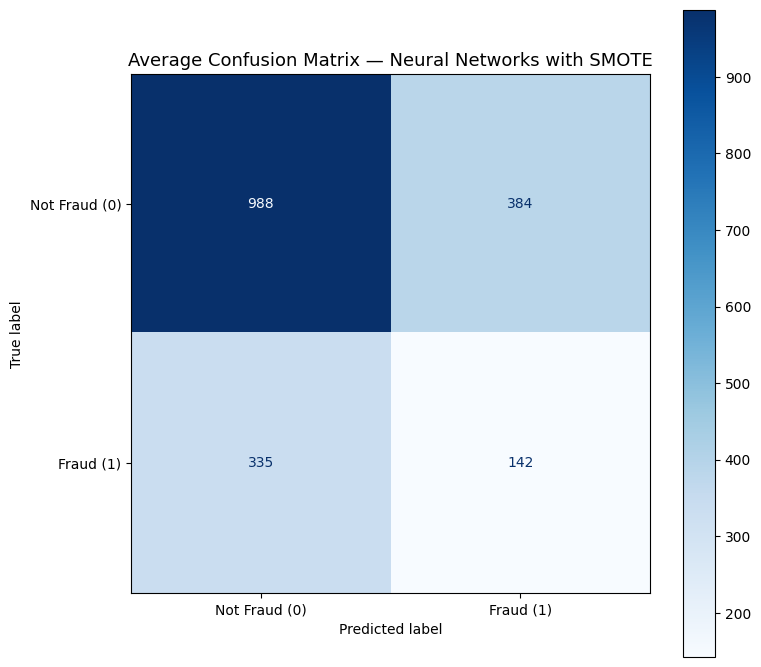

In [7]:
print("Running Neural Networks 100 times with SMOTE...")
metrics = {
    "Type I Error (FPR)": [],
    "Type II Error (FNR)": [],
    "Classification Error Rate": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
    "AUC": [],
}

# Structures to store ROC curve data for averaging later
tprs = []
mean_fpr = np.linspace(0, 1, 100)
cumulative_cm = np.zeros((2, 2), dtype=int)

for i in range(100):
    # Split data dynamically in each iteration
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale features based on the training set
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Apply SMOTE to oversample the minority class (training data only)
    smote = SMOTE(random_state=i)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # Initialize and train Neural Network
    nn = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=i)
    nn.fit(X_train_resampled, y_train_resampled)

    # Predict on training data (resampled)
    y_train_pred = nn.predict(X_train_resampled)
    train_error = 1 - accuracy_score(y_train_resampled, y_train_pred)

    # Predict on test data
    y_pred = nn.predict(X_test_scaled)
    y_pred_proba = nn.predict_proba(X_test_scaled)[:, 1]
    test_error = 1 - accuracy_score(y_test, y_pred)

    # Calculate confusion matrix and metrics
    cm = confusion_matrix(y_test, y_pred)
    cumulative_cm += cm
    tn, fp, fn, tp = cm.ravel()

    type_1_error = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    type_2_error = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    class_error_rate = 1 - accuracy_score(y_test, y_pred)  # 1 - Accuracy

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Calculate ROC metrics
    fpr_curve, tpr_curve, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr_curve, tpr_curve)

    # Interpolate TPR so it can be averaged across 100 runs
    interp_tpr = np.interp(mean_fpr, fpr_curve, tpr_curve)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    # Store metrics
    metrics["Type I Error (FPR)"].append(type_1_error)
    metrics["Type II Error (FNR)"].append(type_2_error)
    metrics["Classification Error Rate"].append(class_error_rate)
    metrics["Precision"].append(precision)
    metrics["Recall"].append(recall)
    metrics["F1 Score"].append(f1)
    metrics["AUC"].append(roc_auc)

metrics_df = pd.DataFrame(metrics)

# Print a summary of the results
print("\n--- Metrics Summary over 100 Runs ---")
print(metrics_df.describe().T[["mean", "std", "min", "max"]])

# Display average confusion matrix
avg_cm = cumulative_cm // 100
print(f"\n--- Average Confusion Matrix over 100 Runs (Neural Networks) ---")
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm, display_labels=["Not Fraud (0)", "Fraud (1)"]
)
disp.plot(cmap="Blues", ax=ax, values_format="d")
ax.set_title("Average Confusion Matrix — Neural Networks with SMOTE", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
print(classification_report(y_test, y_pred, target_names=["Not Fraud", "Fraud"]))

              precision    recall  f1-score   support

   Not Fraud       0.75      0.69      0.72      1373
       Fraud       0.26      0.32      0.29       477

    accuracy                           0.60      1850
   macro avg       0.51      0.51      0.50      1850
weighted avg       0.62      0.60      0.61      1850



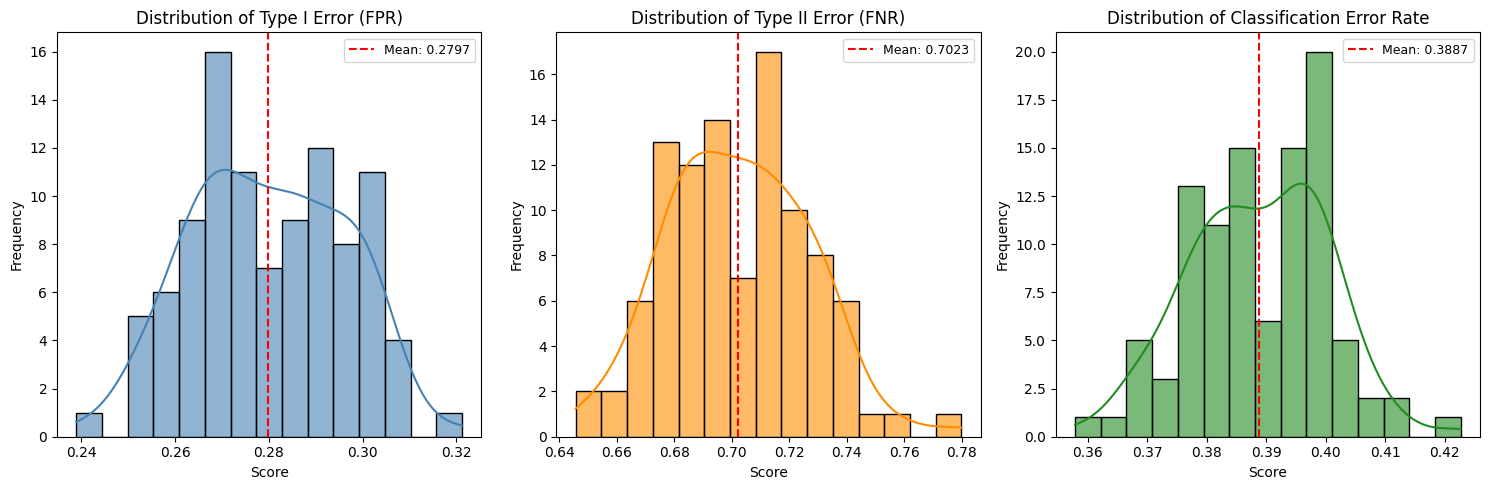

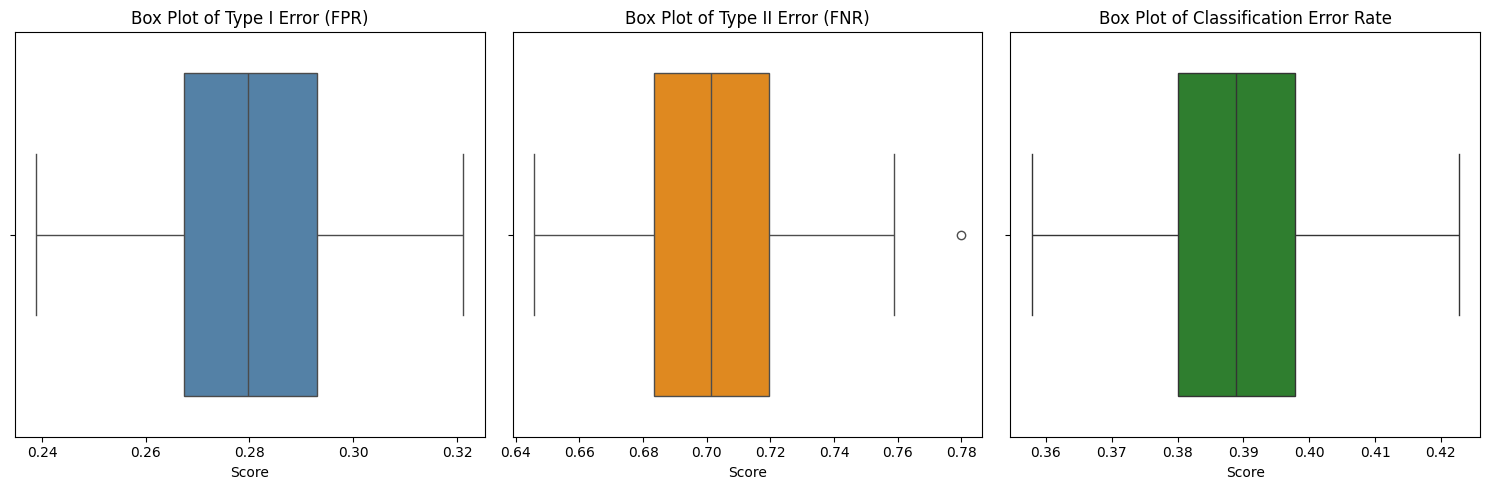

In [9]:
color_map = {
    "Type I Error (FPR)": "#4682B4",
    "Type II Error (FNR)": "#FF8C00",
    "Classification Error Rate": "#228B22",
    "Precision": "#9467BD",
    "Recall": "#E377C2",
    "F1 Score": "#D62728",
    "AUC": "#17BECF",
}

cols_to_plot = [
    "Type I Error (FPR)",
    "Type II Error (FNR)",
    "Classification Error Rate",
]

# Distributions with mean lines
plt.figure(figsize=(15, 5))
for idx, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 3, idx)
    c = color_map.get(col, "#6495ED")
    sns.histplot(metrics_df[col], kde=True, bins=15, color=c, alpha=0.6)
    mean_val = metrics_df[col].mean()
    plt.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean: {mean_val:.4f}",
    )
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Separated Box Plots
plt.figure(figsize=(15, 5))
for idx, col in enumerate(cols_to_plot, 1):
    plt.subplot(1, 3, idx)
    sns.boxplot(x=metrics_df[col], color=color_map.get(col, "#6495ED"))
    plt.title(f"Box Plot of {col}", fontsize=12)
    plt.xlabel("Score")
plt.tight_layout()
plt.show()

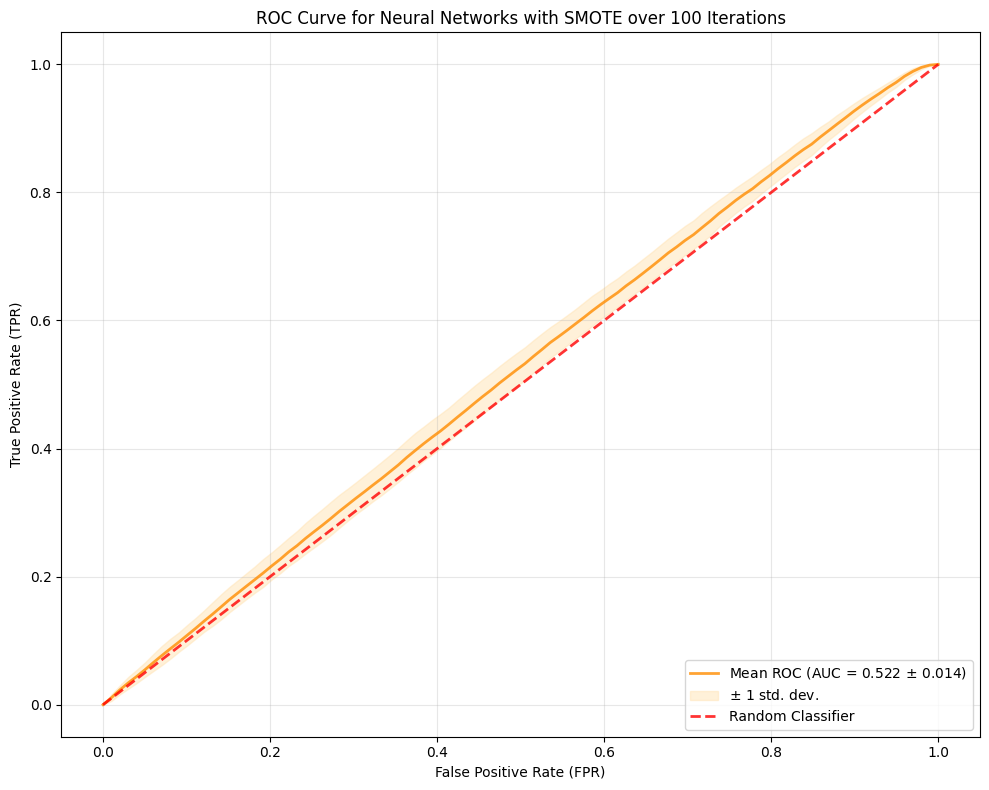

In [10]:
# Mean ROC Curve over 100 Runs
plt.figure(figsize=(10, 8))
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(metrics["AUC"])
std_auc = np.std(metrics["AUC"])
plt.plot(
    mean_fpr,
    mean_tpr,
    color="#FF8C00",
    label=r"Mean ROC (AUC = %0.3f $\pm$ %0.3f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

# Calculate and plot standard deviation bands
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="#FFE4B5",
    alpha=0.5,
    label=r"$\pm$ 1 std. dev.",
)

# Add random baseline and formatting
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    lw=2,
    color="red",
    label="Random Classifier",
    alpha=0.8,
)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Neural Networks with SMOTE over 100 Iterations")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()